# Criterios de Partición en Árboles de Clasificación
**Dataset:** Motor Trend Car Road Tests (mtcars)  


|                |   |
:----------------|---|
| **Nombre**     |  Jorge Oviedo Magaña |
| **Fecha**      | 08/05/2026 |
| **Expediente** |  757048 | 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('Motor Trend Car Road Tests.xlsx')

# Variable objetivo: am (0=automática, 1=manual)
# Variable de entrada: hp (caballos de fuerza)
X = df['hp'].values
y = df['am'].values

print(f'Total de muestras: {len(y)}')
print(f'Automáticas (am=0): {(y==0).sum()}')
print(f'Manuales    (am=1): {(y==1).sum()}')
print(f'\nRango de hp: {X.min()} - {X.max()}')

Total de muestras: 32
Automáticas (am=0): 19
Manuales    (am=1): 13

Rango de hp: 52 - 335


---
## Funciones auxiliares

In [3]:
def gini(y):
    """Gini = 1 - sum(pk^2)"""
    if len(y) == 0:
        return 0
    p = np.mean(y)  # proporción clase 1
    return 1 - (p**2 + (1-p)**2)

def entropy(y):
    """Entropía = -sum(pk * log2(pk))"""
    if len(y) == 0:
        return 0
    p = np.mean(y)
    if p == 0 or p == 1:
        return 0
    return -(p * np.log2(p) + (1-p) * np.log2(1-p))

def log_loss(y):
    """Log Loss usando p_hat = proporción del nodo"""
    if len(y) == 0:
        return 0
    p = np.clip(np.mean(y), 1e-9, 1 - 1e-9)
    return -(p * np.log(p) + (1-p) * np.log(1-p))

def weighted(metric_fn, y_left, y_right):
    """Métrica ponderada por tamaño de hijos"""
    n = len(y_left) + len(y_right)
    return (len(y_left)/n) * metric_fn(y_left) + (len(y_right)/n) * metric_fn(y_right)

print('Funciones definidas: gini(), entropy(), log_loss(), weighted()')

Funciones definidas: gini(), entropy(), log_loss(), weighted()


---
## 1. Índice de Gini

$$\text{Gini}(t) = 1 - \sum_k p_k^2$$

Se busca el umbral que **minimiza** el Gini ponderado de los dos nodos hijo.

Umbral óptimo (Gini):  hp <= 113
Gini ponderado mínimo: 0.3627

Nodo izquierdo (hp <= 113): n=15, auto=5, manual=10, Gini=0.4444
Nodo derecho   (hp >  113): n=17, auto=14, manual=3, Gini=0.2907


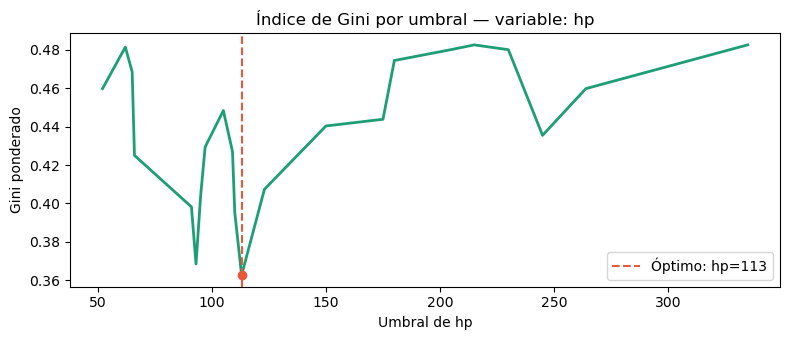

In [4]:
thresholds = np.unique(X)
gini_scores = []

for t in thresholds:
    left  = y[X <= t]
    right = y[X > t]
    gini_scores.append(weighted(gini, left, right))

best_idx = np.argmin(gini_scores)
best_t   = thresholds[best_idx]
best_g   = gini_scores[best_idx]

# Nodos resultantes
left_node  = y[X <= best_t]
right_node = y[X > best_t]

print(f'Umbral óptimo (Gini):  hp <= {best_t}')
print(f'Gini ponderado mínimo: {best_g:.4f}')
print()
print(f'Nodo izquierdo (hp <= {best_t}): n={len(left_node)}, '
      f'auto={( left_node==0).sum()}, manual={( left_node==1).sum()}, '
      f'Gini={gini(left_node):.4f}')
print(f'Nodo derecho   (hp >  {best_t}): n={len(right_node)}, '
      f'auto={(right_node==0).sum()}, manual={(right_node==1).sum()}, '
      f'Gini={gini(right_node):.4f}')

# Gráfica
plt.figure(figsize=(8, 3.5))
plt.plot(thresholds, gini_scores, color='#1D9E75', linewidth=2)
plt.axvline(best_t, color='#E8593C', linestyle='--', label=f'Óptimo: hp={best_t}')
plt.scatter([best_t], [best_g], color='#E8593C', zorder=5)
plt.xlabel('Umbral de hp'); plt.ylabel('Gini ponderado')
plt.title('Índice de Gini por umbral — variable: hp')
plt.legend(); plt.tight_layout(); plt.show()

---
## 2. Entropía (Ganancia de Información)

$$H(t) = -\sum_k p_k \log_2(p_k)$$
$$IG = H(\text{padre}) - \left[\frac{n_L}{n}H(L) + \frac{n_R}{n}H(R)\right]$$

Se busca el umbral que **maximiza** la ganancia de información.

Umbral óptimo (Entropía): hp <= 113
Ganancia de información:  0.1869 bits
Entropía padre:           0.9745 bits

Nodo izquierdo (hp <= 113): n=15, auto=5, manual=10, H=0.9183
Nodo derecho   (hp >  113): n=17, auto=14, manual=3, H=0.6723


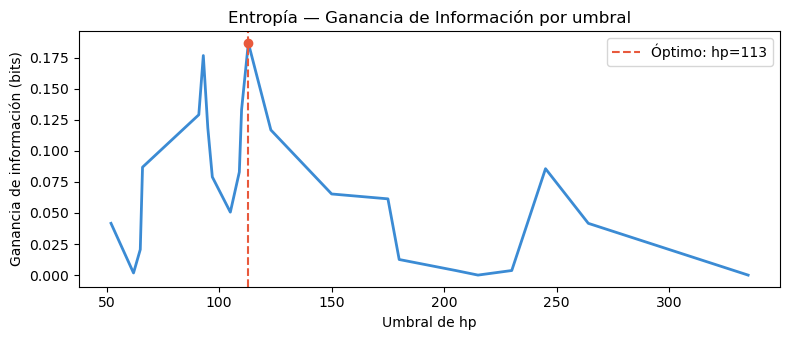

In [5]:
parent_entropy = entropy(y)
ig_scores = []

for t in thresholds:
    left  = y[X <= t]
    right = y[X > t]
    ig_scores.append(parent_entropy - weighted(entropy, left, right))

best_idx = np.argmax(ig_scores)
best_t   = thresholds[best_idx]
best_ig  = ig_scores[best_idx]

left_node  = y[X <= best_t]
right_node = y[X > best_t]

print(f'Umbral óptimo (Entropía): hp <= {best_t}')
print(f'Ganancia de información:  {best_ig:.4f} bits')
print(f'Entropía padre:           {parent_entropy:.4f} bits')
print()
print(f'Nodo izquierdo (hp <= {best_t}): n={len(left_node)}, '
      f'auto={( left_node==0).sum()}, manual={( left_node==1).sum()}, '
      f'H={entropy(left_node):.4f}')
print(f'Nodo derecho   (hp >  {best_t}): n={len(right_node)}, '
      f'auto={(right_node==0).sum()}, manual={(right_node==1).sum()}, '
      f'H={entropy(right_node):.4f}')

# Gráfica
plt.figure(figsize=(8, 3.5))
plt.plot(thresholds, ig_scores, color='#3B8BD4', linewidth=2)
plt.axvline(best_t, color='#E8593C', linestyle='--', label=f'Óptimo: hp={best_t}')
plt.scatter([best_t], [best_ig], color='#E8593C', zorder=5)
plt.xlabel('Umbral de hp'); plt.ylabel('Ganancia de información (bits)')
plt.title('Entropía — Ganancia de Información por umbral')
plt.legend(); plt.tight_layout(); plt.show()

---
## 3. Log Loss

$$\mathcal{L} = -\frac{1}{n}\sum_i \left[y_i \log(\hat{p}) + (1-y_i)\log(1-\hat{p})\right]$$

Donde $\hat{p} = p_k$ (la proporción real del nodo). Se busca el umbral que **minimiza** el Log Loss ponderado.

Umbral óptimo (Log Loss): hp <= 113
Log Loss ponderado mín:   0.5459

Nodo izquierdo (hp <= 113): n=15, auto=5, manual=10, LL=0.6365
Nodo derecho   (hp >  113): n=17, auto=14, manual=3, LL=0.4660


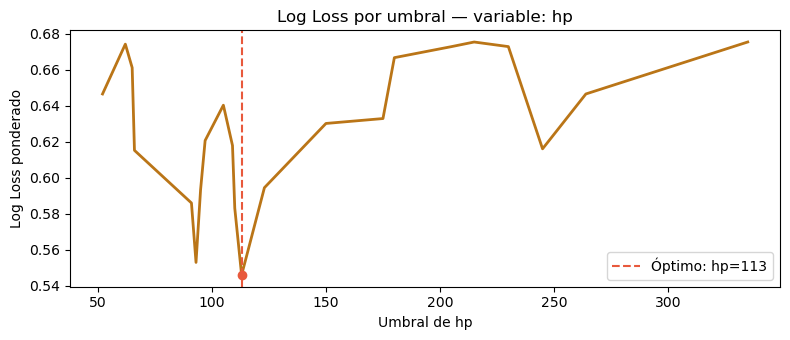

In [6]:
ll_scores = []

for t in thresholds:
    left  = y[X <= t]
    right = y[X > t]
    ll_scores.append(weighted(log_loss, left, right))

best_idx = np.argmin(ll_scores)
best_t   = thresholds[best_idx]
best_ll  = ll_scores[best_idx]

left_node  = y[X <= best_t]
right_node = y[X > best_t]

print(f'Umbral óptimo (Log Loss): hp <= {best_t}')
print(f'Log Loss ponderado mín:   {best_ll:.4f}')
print()
print(f'Nodo izquierdo (hp <= {best_t}): n={len(left_node)}, '
      f'auto={( left_node==0).sum()}, manual={( left_node==1).sum()}, '
      f'LL={log_loss(left_node):.4f}')
print(f'Nodo derecho   (hp >  {best_t}): n={len(right_node)}, '
      f'auto={(right_node==0).sum()}, manual={(right_node==1).sum()}, '
      f'LL={log_loss(right_node):.4f}')

# Gráfica
plt.figure(figsize=(8, 3.5))
plt.plot(thresholds, ll_scores, color='#BA7517', linewidth=2)
plt.axvline(best_t, color='#E8593C', linestyle='--', label=f'Óptimo: hp={best_t}')
plt.scatter([best_t], [best_ll], color='#E8593C', zorder=5)
plt.xlabel('Umbral de hp'); plt.ylabel('Log Loss ponderado')
plt.title('Log Loss por umbral — variable: hp')
plt.legend(); plt.tight_layout(); plt.show()

---
## Resumen comparativo

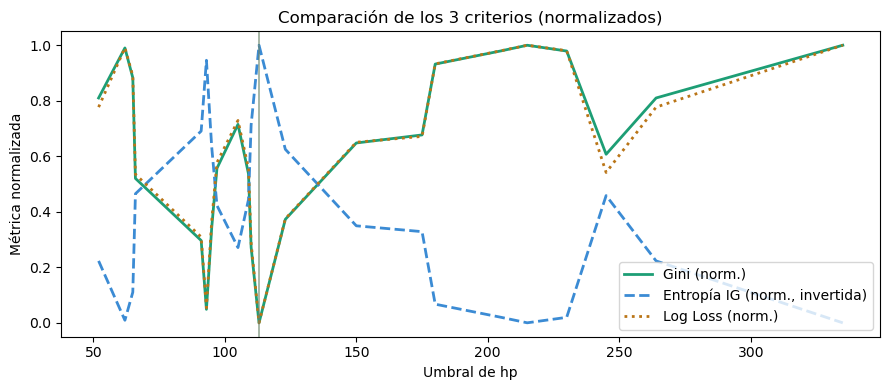

Umbral óptimo por criterio:
  Gini:     hp <= 113
  Entropía: hp <= 113
  Log Loss: hp <= 113


In [7]:
# Normalizar para graficar en la misma escala
def normalize(arr):
    mn, mx = min(arr), max(arr)
    return [(v - mn) / (mx - mn) for v in arr]

plt.figure(figsize=(9, 4))
plt.plot(thresholds, normalize(gini_scores),  color='#1D9E75', linewidth=2, label='Gini (norm.)')
plt.plot(thresholds, normalize(ig_scores),    color='#3B8BD4', linewidth=2, linestyle='--', label='Entropía IG (norm., invertida)')
plt.plot(thresholds, normalize(ll_scores),    color='#BA7517', linewidth=2, linestyle=':',  label='Log Loss (norm.)')

# Marcar óptimos
g_opt  = thresholds[np.argmin(gini_scores)]
e_opt  = thresholds[np.argmax(ig_scores)]
ll_opt = thresholds[np.argmin(ll_scores)]

for t, c in [(g_opt,'#1D9E75'), (e_opt,'#3B8BD4'), (ll_opt,'#BA7517')]:
    plt.axvline(t, color=c, alpha=0.3, linewidth=1.2)

plt.xlabel('Umbral de hp')
plt.ylabel('Métrica normalizada')
plt.title('Comparación de los 3 criterios (normalizados)')
plt.legend()
plt.tight_layout()
plt.show()

print('Umbral óptimo por criterio:')
print(f'  Gini:     hp <= {g_opt}')
print(f'  Entropía: hp <= {e_opt}')
print(f'  Log Loss: hp <= {ll_opt}')